In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import arviz as az
from scipy.stats import norm
import imageio.v2 as imageio
from scipy.stats import gaussian_kde
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib import colors
from matplotlib.colors import Normalize
from reweighting import x_samps, x_resampled

In [2]:
iData = az.from_netcdf('./samples.nc')
samples = iData.posterior['x'].values
bias_values = iData.sample_stats['bias_value'].values
delF = iData.sample_stats['delta_F'].values
acceptance = iData.sample_stats['acceptance_rate'].values
energy_values = -iData.sample_stats['lp'].values
n_steps = iData.sample_stats['n_steps'].values
print(n_steps)



resampled_samples = x_resampled

[[700 700 700 ... 700 700 700]
 [700 700 700 ... 700 700 700]
 [700 700 700 ... 700 700 700]
 [700 700 700 ... 700 700 700]]


In [3]:
print(np.shape(samples))
print(samples[0, 0, :])
print(np.shape(acceptance))
print(delF[0, :, 1])
print(bias_values)

(4, 100000, 2)
[-1.15963671  0.49391151]
(4, 100000)
[-4.78173647 -3.89671442 -3.89588315 ... -0.89050064 -0.89050851
 -0.89051716]
[[ 1.32375991  0.14070295  0.94137527 ... -1.98584445 -1.1991342
  -0.26626983]
 [ 1.94455353  1.93836522  1.92939471 ... -0.37158727  0.77818294
   0.52507305]
 [ 1.89023959  1.93725522  1.92687634 ... -0.591939    1.1165954
   1.1625335 ]
 [-3.66855728  1.75014792  1.92967435 ... -0.8323225  -3.13362031
  -7.50027709]]


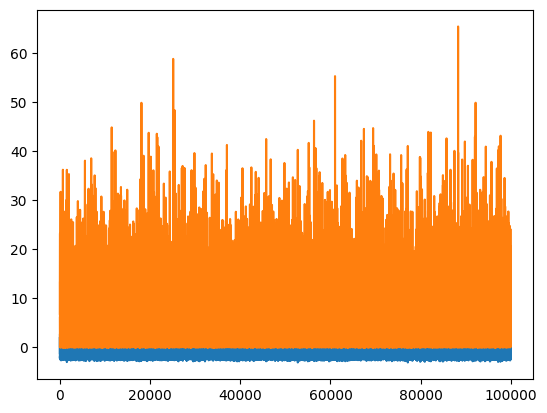

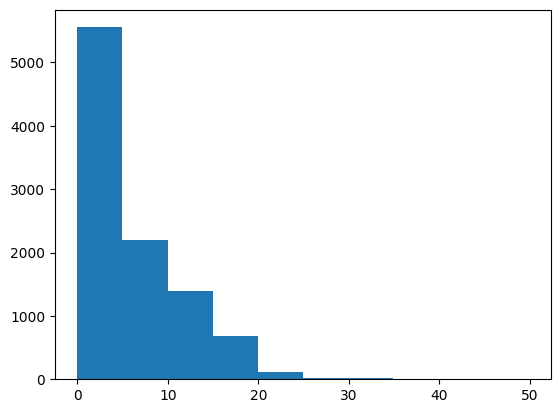

In [4]:
plt.figure()
# plt.plot(bias_values[0,:])
plt.plot(samples[0,:, 0])
plt.plot(energy_values[0, :])
plt.show()

plt.figure()
plt.hist(energy_values[0,::10])
plt.show()

In [5]:
def energy_function(variables):
    return 1.34549*variables[0]**4 + 1.90211*variables[0]**3*variables[1]+ 3.92705*variables[0]**2*variables[1]**2-6.44246*variables[0]**2- 1.90211*variables[0]*variables[1]**3+5.58721*variables[0]*variables[1] + 1.33481*variables[0] + 1.34549*variables[1]**4- 5.55754*variables[1]**2+0.904586*variables[1] + 18.5598

In [6]:
x = np.linspace(-3, 3, 1000)
y = np.linspace(-3, 3, 1000)
dx, dy = x[1]-x[0], y[1]-y[0]
X, Y = np.meshgrid(x, y, indexing="xy")

U = energy_function([X, Y])

P = np.exp(-U)
P/=np.sum(P)*dx*dy
true_marginal_likelihood = np.sum(P, axis = 0) * dy
free_energy = -np.log(true_marginal_likelihood)
free_energy-= np.min(free_energy)

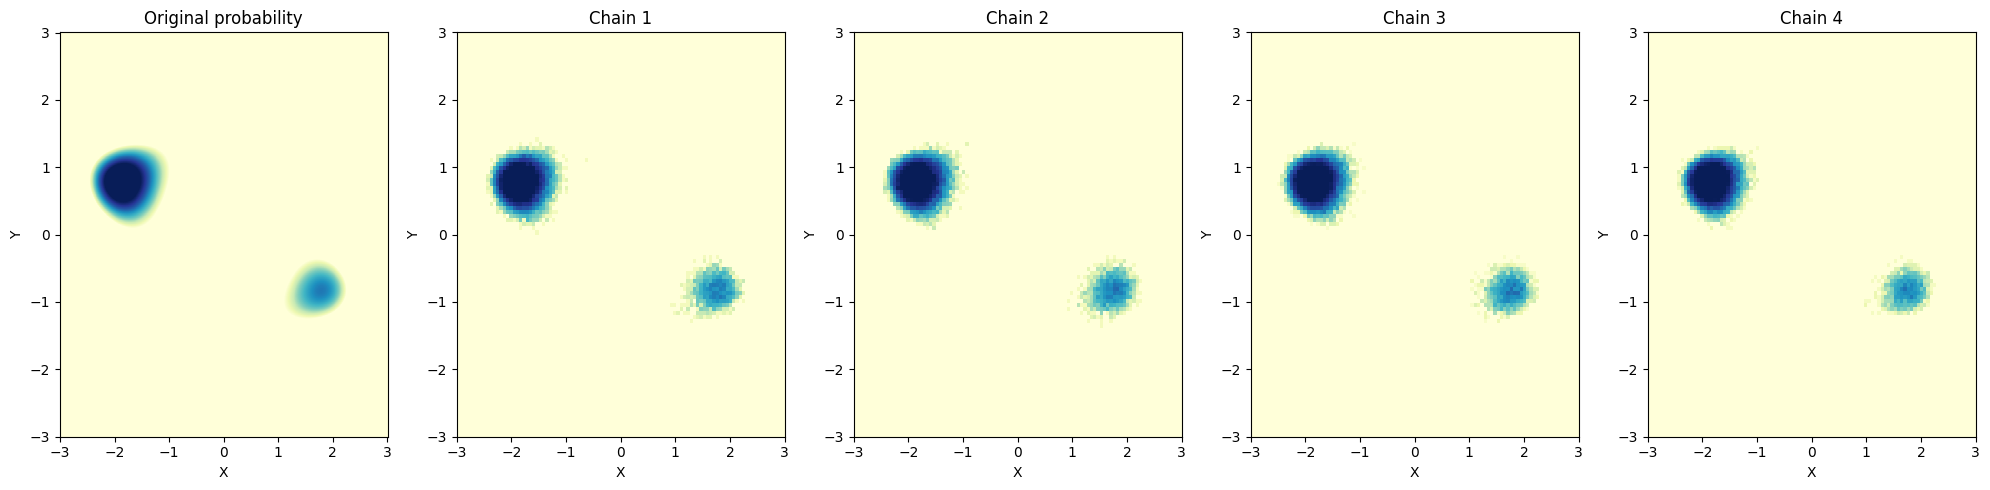

In [7]:
fig, axs= plt.subplots(1, 4 + 1, figsize=(5*4, 5))
norm = colors.Normalize(vmin=P.min(), vmax=P.max())

axs[0].pcolormesh(X, Y, -np.log(P), cmap="YlGnBu_r", norm = norm, shading = "auto")
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].set_title(f"Original probability")

for i in range(1, 4 + 1):
    # Compute a 2D histogram and normalize to get a probability density
    hist, xedges, yedges = np.histogram2d(
        resampled_samples[i-1, :, 0], resampled_samples[i-1, :, 1],
        bins=100, range=[[-3, 3], [-3, 3]], density=True
    )

    # Grid centers
    xpos = (xedges[:-1] + xedges[1:]) / 2
    ypos = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(xpos, ypos, indexing='ij')

    # Plot as a 2D color map
    cmap = cm.YlGnBu_r
    norm = colors.Normalize(vmin=hist.min(), vmax=hist.max())
    pcm = axs[i].pcolormesh(X, Y, -np.log(hist + 1e-12), cmap=cmap, norm=norm, shading='auto')

    axs[i].set_xlabel("X")
    axs[i].set_ylabel("Y")
    axs[i].set_title(f"Chain {i}")

plt.tight_layout()
plt.show()

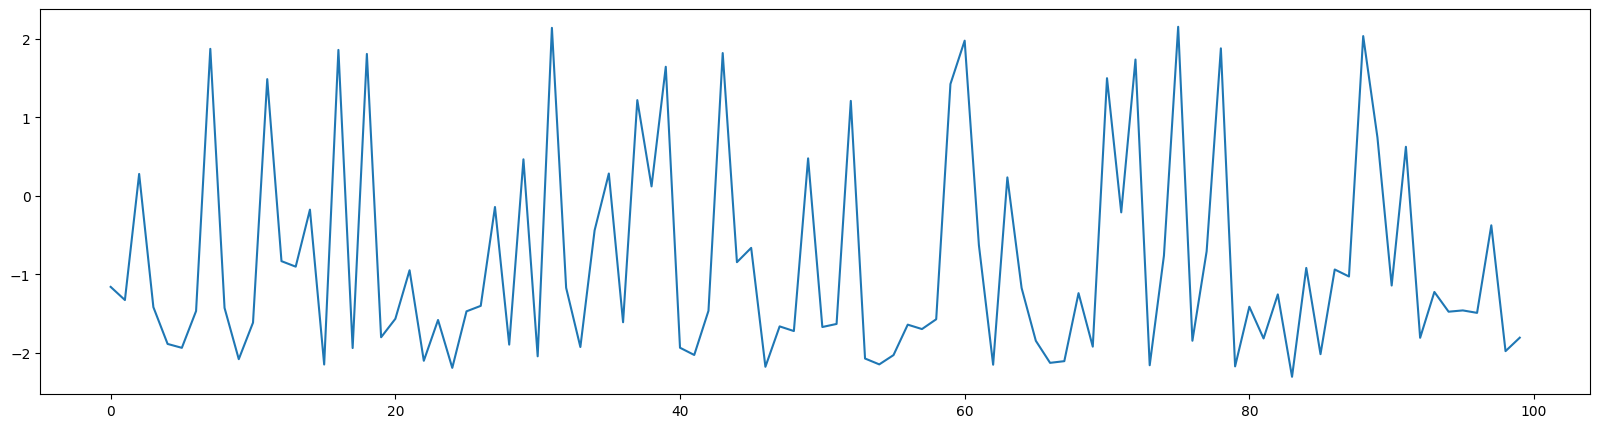

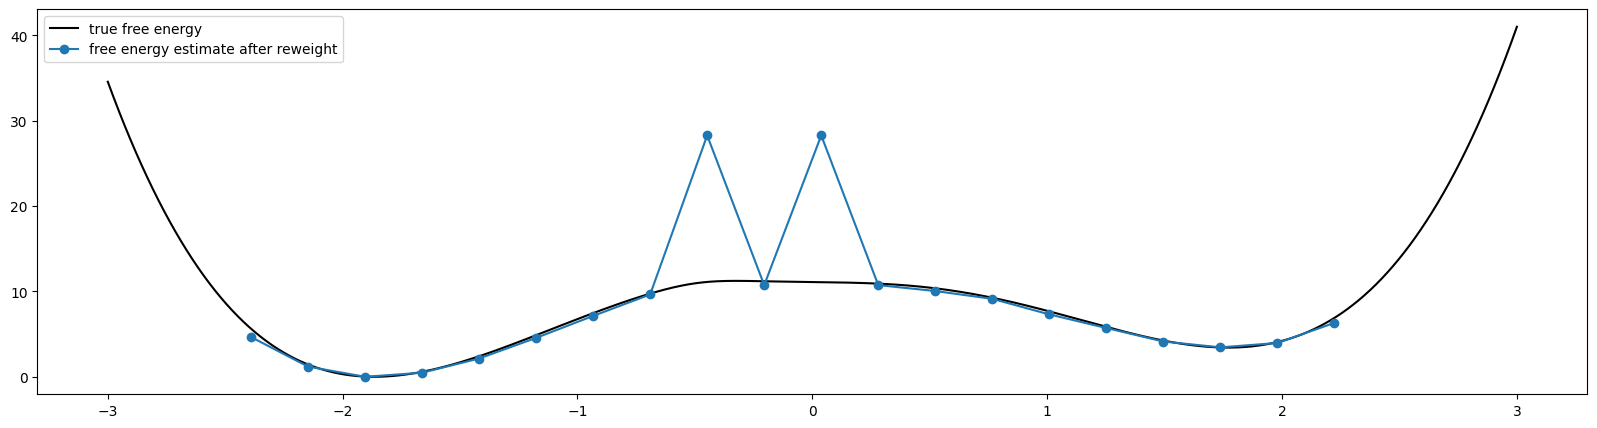

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5*4, 5))
plt.plot(samples[0,::1000,0])
# plt.hist(samples[0,:,0], bins = 100)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5*4, 5))
counts, bin_edges = np.histogram(resampled_samples[0,:, 0], bins=20, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
counts[counts == 0] = 1e-12  
free_energy_est_reweight = -np.log(counts)
free_energy_est_reweight-= np.min(free_energy_est_reweight)
ax.plot(x, free_energy, color="black", label=f"true free energy")
ax.plot(bin_centers, free_energy_est_reweight, '-o', label="free energy estimate after reweight")
# ax.plot(np.linspace(-3, 3, config["num_lambda"]), delF[0, -1, :] - np.min(delF[0, -1, :]))
plt.legend()
plt.show()

In [9]:
# import matplotlib.animation as animation
# from IPython.display import Image
# from IPython.display import HTML


# # Create the animation
# fig, ax = plt.subplots()
# x_vec = np.vstack((x, -np.ones_like(x)))
# energy_range = np.array([energy_function(x_vec[:, i]) for i in range(len(x_vec[0, :]))])
# line, = ax.plot(x, energy_range)
# ax.set_ylim(0, 40)
# ax.set_xlim(-3, 3)


# frames = 100
# E_lambdas = np.linspace(1, config["num_temps"], config["num_temps"])
# print(delF[0, :, 3])

# def update(frame):
#     # shape (1000, num_lambda)
#     factor = -((energy_range[:, None] - E_lambdas[None, :])**2) / (2 * config["sigma"]**2)

#     # get delF slice
#     delF_frame = delF[0, frame, :]

#     # stable log-sum-exp
#     log_terms = factor + delF_frame[None, :]
#     max_term = np.max(log_terms, axis=1)          # shape (1000,)
#     bias = - max_term - np.log(np.mean(np.exp(log_terms - max_term[:, None]), axis=1))
#     # print(frame)
#     # print(bias[0])
#     # print(bias[50])

#     # update free-energy estimate
#     to_plot = energy_range + bias
#     line.set_ydata(to_plot - np.min(to_plot))

#     return line,

# ani = animation.FuncAnimation(fig, update, frames=frames, blit=False)

# HTML(ani.to_jshtml())
# # ani.save("sinewave.gif", writer="pillow", fps=30)
# # plt.close(fig)

# # # Display it in the notebook
# # display(Image(filename="sinewave.gif"))


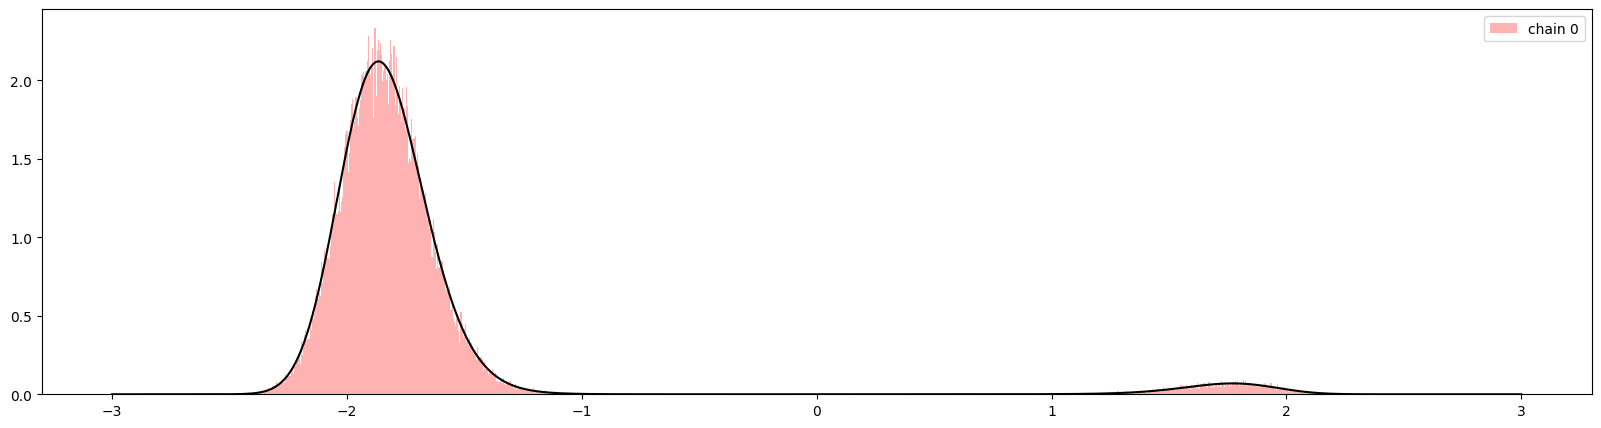

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5*4, 5))
ax.hist(resampled_samples[1, :, 0], bins=1000, color="red", density=True, alpha=0.3, label=f"chain {0}")
ax.legend()
ax.plot(x, true_marginal_likelihood, color="black")
plt.show()